# SPRINT 10: Analítica de dades en Pandas

## NIVELL 1

1. Importa com un DataFrame l'arxiu sprint10.xlsx. Assegura't que el fitxer s'importa correctament, amb els noms de columnes que li corresponen, sense manipular l'arxiu original.

Ordena el DataFrame pel país d'origen. En cas d'empat, ordena pel nom de la ciutat.

Mostra les primeres 10 files.

Addicionalment, fes un print on comprovi que el DNI només té valors únics.

In [20]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import pandas as pd
import numpy as np

df = pd.read_excel('sprint10.xlsx', skiprows=3, index_col=0)
df_ordenat = df.sort_values(by=["País d'origen", 'Ciutat'])
print(df_ordenat.head(10))

if df['DNI'].is_unique:
    print('\nTots els DNI són únics.')
else:
    print('\nAlgun DNI es repeteix.')

       Nom              Cognoms        DNI País d'origen   Ciutat  \
21     Mia    Schneider Fischer  28973553Z      Alemanya   Berlín   
154  Laura    Schneider Fischer  37399141L      Alemanya   Berlín   
224    Lea  Schneider Schneider  37368317L      Alemanya   Berlín   
278    Mia              Fischer  21390098Z      Alemanya   Berlín   
602  Jonas            Schneider  44060014R      Alemanya   Berlín   
871    Lea              Fischer  14773153R      Alemanya   Berlín   
281    Lea               Müller  23266650S      Alemanya  Hamburg   
435   Anna               Müller  83274277X      Alemanya  Hamburg   
444  Laura       Schmidt Müller  60161784X      Alemanya  Hamburg   
487  Lukas       Müller Fischer  60982309S      Alemanya  Hamburg   

     Dia de Naixement  Mes de Naixement  Any de Naixement Gènere  \
21                 22                10              1976      A   
154                 2                 2              1958      D   
224                23               

2. Crea una columna que sigui el nom complet.

Crea una columna si la persona és nascuda a Espanya o no.

Posa el DNI com a índex del DataFrame (noms de files).

Substitueix el nom de les columnes Dia de Naixement, Mes de Naixement i Any de Naixement per Dia, Mes i Any.

Substitueix H per Home, D per Dona, A per Altres i NC per una dada faltant (nan/null/na).

Mostra tots els canvis que has realitzat en una sola taula.

In [22]:
df['Nom_complet'] = df['Nom'] + ' ' + df['Cognoms']
df['Resident'] = np.where(df["País d'origen"] == 'Espanya', 'Nascut a Espanya', "Nascut fora d'Espanya")
df = df.set_index('DNI')
df_modificat = df.rename(columns= {'Dia de Naixement': 'Dia', 'Mes de Naixement': 'Mes', 'Any de Naixement': 'Any'})
df_modificat['Gènere'] = df_modificat['Gènere'].replace({
    'H': 'Home',
    'D': 'Dona',
    'A': 'Altres',
    'NC': np.nan
})
nova_taula= df_modificat[['Nom_complet', 'Resident', 'Dia', 'Mes', 'Any', 'Gènere']]
nova_taula

,Nom_complet,Resident,Dia,Mes,Any,Gènere
DNI,,,,,,
16928694K,Inês Ferreira Silva,Nascut fora d'Espanya,25,2,1953,Dona
27724652S,Clara Sánchez Martínez,Nascut a Espanya,18,3,1996,Dona
38141675A,Fatima Fassi,Nascut fora d'Espanya,6,11,2005,Altres
59157262R,Khadija Bennani Bennani,Nascut fora d'Espanya,20,1,1995,Dona
69630528M,Toni Sánchez García,Nascut a Espanya,9,8,1999,Home
...,...,...,...,...,...,...
25161375F,Marta Ferrer Ferrer,Nascut a Espanya,1,6,1951,Dona
52145541P,Joan García,Nascut a Espanya,11,4,1959,Home
69760120X,Laia Ferrer Martínez,Nascut a Espanya,11,11,1980,Dona


3. Junta les columnes Fills i No Fills en una sola columna, utilitzant el mètode .apply() i definint una funció que resolgui el problema. La columna nova ha de dir-se "Fills" i prendre els valors "Sí" o "No".

In [23]:
def te_fills(fila):
    if fila['Fills'] == 1.0:
        return 'Sí'
    elif fila['No Fills'] == 1.0:
        return 'No'
    else:
        return 'Dada no disponible' # Per si ambdues estan buidas
    
df_modificat['Fills'] = df_modificat.apply(te_fills, axis = 1)
df_modificat = df_modificat.drop('No Fills', axis=1)
df_modificat

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Nom_complet,Resident
DNI,,,,,,,,,,,,,
16928694K,Inês,Ferreira Silva,Portugal,Lisboa,25,2,1953,Dona,1.144 €,No,Grup B,Inês Ferreira Silva,Nascut fora d'Espanya
27724652S,Clara,Sánchez Martínez,Espanya,Barcelona,18,3,1996,Dona,1.253 €,Sí,Grup A,Clara Sánchez Martínez,Nascut a Espanya
38141675A,Fatima,Fassi,Marroc,Rabat,6,11,2005,Altres,1.441 €,Sí,Grup A,Fatima Fassi,Nascut fora d'Espanya
59157262R,Khadija,Bennani Bennani,Marroc,Rabat,20,1,1995,Dona,1.944 €,No,Grup B,Khadija Bennani Bennani,Nascut fora d'Espanya
69630528M,Toni,Sánchez García,Espanya,Barcelona,9,8,1999,Home,1.043 €,No,Grup A,Toni Sánchez García,Nascut a Espanya
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta,Ferrer Ferrer,Espanya,Sevilla,1,6,1951,Dona,1.216 €,No,Grup B,Marta Ferrer Ferrer,Nascut a Espanya
52145541P,Joan,García,Espanya,Sevilla,11,4,1959,Home,971 €,No,Grup A,Joan García,Nascut a Espanya
69760120X,Laia,Ferrer Martínez,Espanya,Barcelona,11,11,1980,Dona,682 €,No,Grup A,Laia Ferrer Martínez,Nascut a Espanya


4. Crea una taula resum que permeti veure el sou mig, medià, mínim i màxim per Gènere.

Ordena la taula en funció del sou mig.

In [24]:
df_modificat['Salari mensual'] = (
    df_modificat['Salari mensual']
    .str.replace('€', '', regex=False) # eliminem el símbol
    .str.replace('.', '', regex=False) # eliminem el punt que està com a separador de milers
    .str.replace(',', '.', regex=False) # per si hi hagués salaris amb decimals amb coma
    .str.strip() # netegem possibles espais blancs abans o després del text
    .astype(float) # convertim a float
)  

taula_resum = df_modificat.groupby(['Gènere'])[['Salari mensual']].agg(['mean','median','min','max']).round(2)
taula_resum = taula_resum.sort_values(by=('Salari mensual','mean'), ascending=False)
taula_resum.columns = ['Mitjana', 'Mediana', 'Mínim', 'Màxim']

taula_resum

,Mitjana,Mediana,Mínim,Màxim
Gènere,,,,
Home,1643.25,1531.0,737.0,3356.0
Altres,1626.59,1545.0,703.0,3175.0
Dona,1469.44,1361.5,665.0,3021.0


5. Crea una taula resum amb el salari mig per gènere (files) i país d'origen (columnes).

Afegeix-hi les mitjanes als marges de la taula.

(EXTRA): Aplica format condicional a la taula per veure en un color més intens els valors més elevats

In [25]:
taula_resum_genere_pais = df_modificat.pivot_table(
    index= 'Gènere',            
    columns= "País d'origen",    
    values= 'Salari mensual',    
    aggfunc= 'mean',                            
    margins= True,                              
    margins_name= 'Mitjana',
    fill_value=0 # per omplir els buits (nan) amb 0 i no trencar el degradat de color                 
)

taula_resum_genere_pais.style\
    .format("{:.2f}")\
    .background_gradient(cmap="YlOrRd") # per aplicar el format condicional

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjana
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,0.00,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mitjana,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


6. Crea una columna nova que sigui la data de naixament en format Datetime a partir de les columnes dia, mes i any. Utilitzant aquesta columna crea una funció que donada una data, et calculi l'edat actual a dia d'avui.

Utilitza la funció que acabes de crear per generar una columna nova al DataFrame amb l'edat actual.

In [26]:
df_modificat['Data de Naixement'] = pd.to_datetime(
    dict(
        day=df_modificat['Dia'],
        month=df_modificat['Mes'],
        year=df_modificat['Any']
    ),
    errors='coerce'
)

# Funció per calcular l'edat actual
def calcular_edat(data_naixeiment):
    if pd.isna(data_naixeiment):
        return pd.NA

    avui = pd.Timestamp.today().normalize()

    edat = avui.year - data_naixeiment.year

    # Comprovar si encara no ha fet els anys aquest any
    if (avui.month, avui.day) < (data_naixeiment.month, data_naixeiment.day):
        edat -= 1

    return edat

# Crear la columna amb l'edat actual
df_modificat['Edat_actual'] = df_modificat['Data de Naixement'].apply(calcular_edat)

df_modificat2 = df_modificat.drop(columns=['Nom','Cognoms','Dia','Mes','Any'])
cols = list(df_modificat2.columns)
cols.insert(0, cols.pop(cols.index('Nom_complet')))
cols.insert(1, cols.pop(cols.index('Gènere')))          # Lo utilizamos para situar una columna en la posición que deseamos
df_modificat2 = df_modificat2[cols]
df_modificat2

,Nom_complet,Gènere,País d'origen,Ciutat,Salari mensual,Fills,Grup Professional,Resident,Data de Naixement,Edat_actual
DNI,,,,,,,,,,
16928694K,Inês Ferreira Silva,Dona,Portugal,Lisboa,1144.0,No,Grup B,Nascut fora d'Espanya,1953-02-25,73
27724652S,Clara Sánchez Martínez,Dona,Espanya,Barcelona,1253.0,Sí,Grup A,Nascut a Espanya,1996-03-18,30
38141675A,Fatima Fassi,Altres,Marroc,Rabat,1441.0,Sí,Grup A,Nascut fora d'Espanya,2005-11-06,20
59157262R,Khadija Bennani Bennani,Dona,Marroc,Rabat,1944.0,No,Grup B,Nascut fora d'Espanya,1995-01-20,31
69630528M,Toni Sánchez García,Home,Espanya,Barcelona,1043.0,No,Grup A,Nascut a Espanya,1999-08-09,26
...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta Ferrer Ferrer,Dona,Espanya,Sevilla,1216.0,No,Grup B,Nascut a Espanya,1951-06-01,74
52145541P,Joan García,Home,Espanya,Sevilla,971.0,No,Grup A,Nascut a Espanya,1959-04-11,67
69760120X,Laia Ferrer Martínez,Dona,Espanya,Barcelona,682.0,No,Grup A,Nascut a Espanya,1980-11-11,45


## NIVELL 2

1. Utilitzant el següent DataFrame, adjunta la columna "Increment" al dataframe del nivell anterior.

Actualitza la columna salari en funció dels percentatges que s'adjunten. No modifiquis manualment els increments, escriu codi Python per fer les conversions necessàries.

df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":

["5%","3,5%","2%","8%"]})

In [27]:
# DataFrame amb increments
df_increment = pd.DataFrame({'Grup': ['Grup A','Grup B','Grup C', 'Grup D'], 'Increment': ['5%','3,5%','2%','8%']})

# Unir els increments al DataFrame principal
df_combinat = pd.merge(df_modificat2,df_increment, left_on='Grup Professional', right_on = 'Grup', how= 'left').drop(columns='Grup')
df_combinat.index = df_modificat2.index # Per mantenir el DNI com a índex

# Convertir percentatges a decimal
df_combinat['Increment'] = (df_combinat['Increment'].str.replace("%","", regex = False).str.replace(",",".", regex = False).astype(float))

# Actualitzar salari
df_combinat['Salari mensual'] = (df_combinat['Salari mensual'] * (1+ df_combinat['Increment']/100)).round(2)

df_combinat

,Nom_complet,Gènere,País d'origen,Ciutat,Salari mensual,Fills,Grup Professional,Resident,Data de Naixement,Edat_actual,Increment
DNI,,,,,,,,,,,
16928694K,Inês Ferreira Silva,Dona,Portugal,Lisboa,1184.04,No,Grup B,Nascut fora d'Espanya,1953-02-25,73,3.5
27724652S,Clara Sánchez Martínez,Dona,Espanya,Barcelona,1315.65,Sí,Grup A,Nascut a Espanya,1996-03-18,30,5.0
38141675A,Fatima Fassi,Altres,Marroc,Rabat,1513.05,Sí,Grup A,Nascut fora d'Espanya,2005-11-06,20,5.0
59157262R,Khadija Bennani Bennani,Dona,Marroc,Rabat,2012.04,No,Grup B,Nascut fora d'Espanya,1995-01-20,31,3.5
69630528M,Toni Sánchez García,Home,Espanya,Barcelona,1095.15,No,Grup A,Nascut a Espanya,1999-08-09,26,5.0
...,...,...,...,...,...,...,...,...,...,...,...
25161375F,Marta Ferrer Ferrer,Dona,Espanya,Sevilla,1258.56,No,Grup B,Nascut a Espanya,1951-06-01,74,3.5
52145541P,Joan García,Home,Espanya,Sevilla,1019.55,No,Grup A,Nascut a Espanya,1959-04-11,67,5.0
69760120X,Laia Ferrer Martínez,Dona,Espanya,Barcelona,716.10,No,Grup A,Nascut a Espanya,1980-11-11,45,5.0


2. Utilitzant un bucle, exporta en 4 fitxers (format .xlsx o .csv) les dades de cada Grup Professional.

Per exemple: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

Exporta un 5è DataFrame en format .xlsx o .csv que contingui quants treballadors hi ha per cada Grup Professional, quin és el seu sou mig i quina és la seva edat mediana.

In [28]:
# Exportar un fitxer per cada grup
Grups = df_combinat['Grup Professional'].unique()

for grup in Grups:
    
    df_grup = df_combinat[df_combinat['Grup Professional'] == grup]
    
    ruta = rf"DataFrames\{grup.replace(' ', '')}.xlsx"
    
    df_grup.to_excel(ruta, index=True)

# Crear resum estadístic
resum = df_combinat.groupby(['Grup Professional']).agg({'Salari mensual':'mean','Edat_actual':'median', 'Grup Professional': 'size'}).round(2)

# Renombrar columnes
resum = resum.rename(columns={'Salari mensual':'Sou_Promig','Edat_actual':'Edat_Mediana', 'Grup Professional': 'Número_de_treballadors'})

# Exportar resum
resum.to_excel('resum_estadístic.xlsx')

## NIVELL 3

1. Crea una funció que prengui un dataframe com a paràmetre d'entrada.

La funció ha de crear (i exportar) un gràfic automàticament per a cada columna del dataframe. Per exemple:

un histograma/boxplot si la variable és numèrica
unes barres dels valors més freqüents si és categòrica
unes barres dels anys més freqüents si la dada està en format data.
La idea és crear una funció que funcioni per qualsevol dataframe, no només amb el que hem treballat fins ara.

Mostra el resultat de la funció en algun dels datasets d’exemple que conté el paquet seaborn. Per exemple, iris, penguins o titanic.

Tingues en consideració que en el següent sprint treballaràs exclusivament amb gràfics. L’objectiu d’aquest exercici no és crear gràfics molt elaborats, sinó resoldre una necessitat de manera ràpida i automàtica.

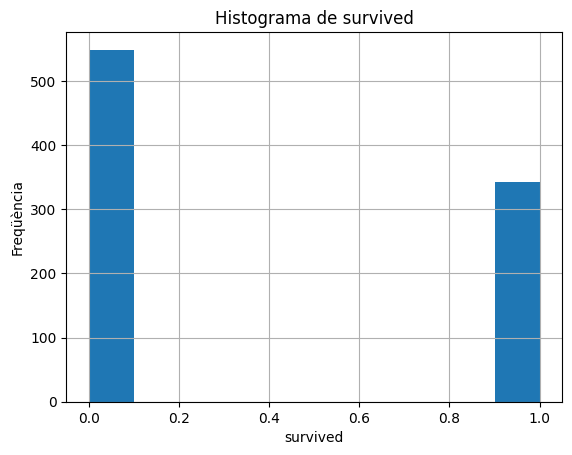

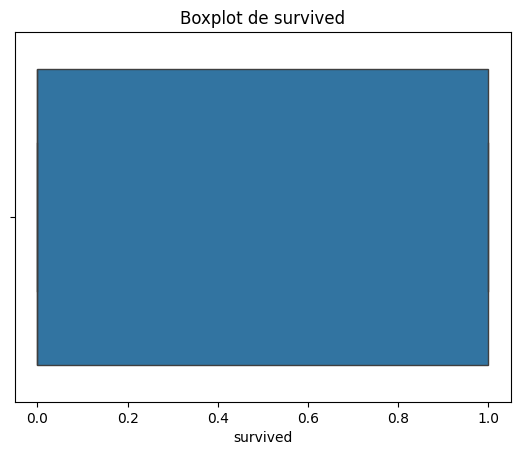

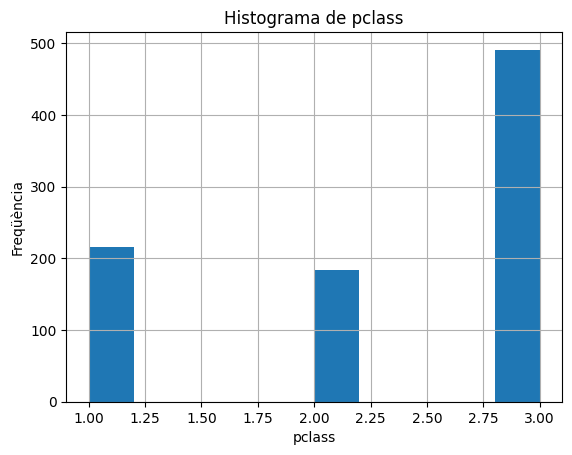

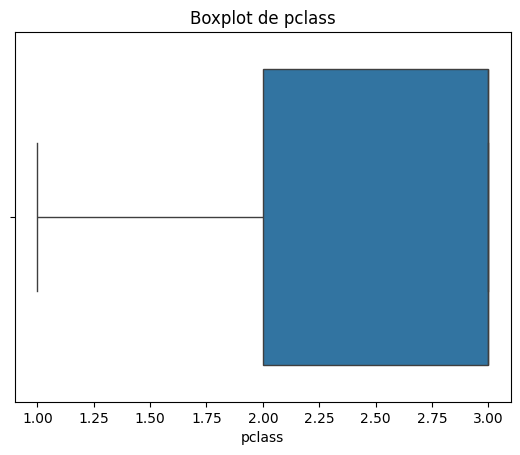

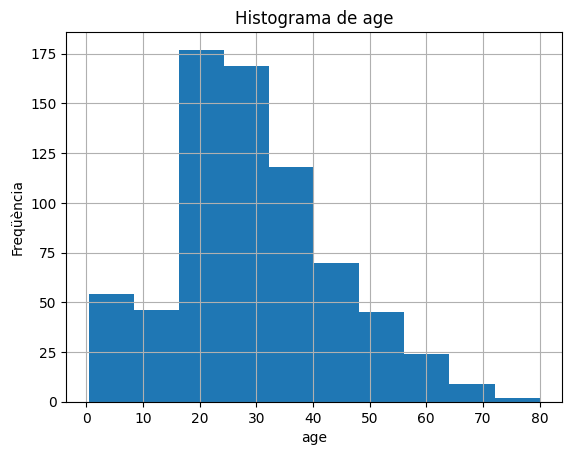

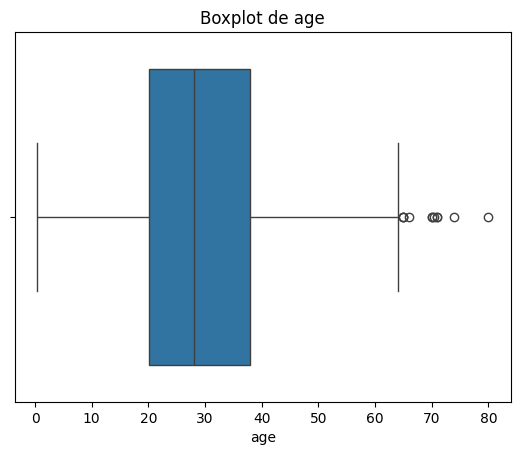

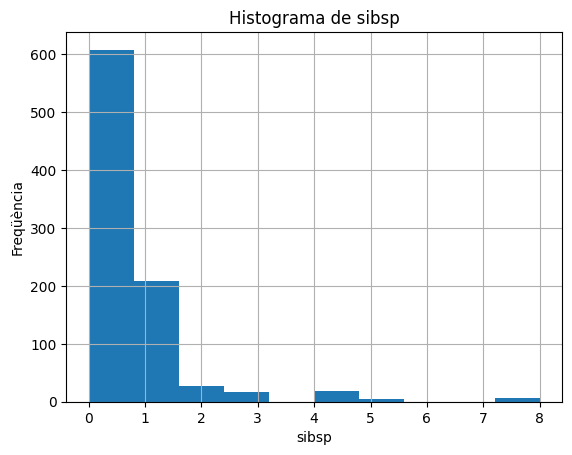

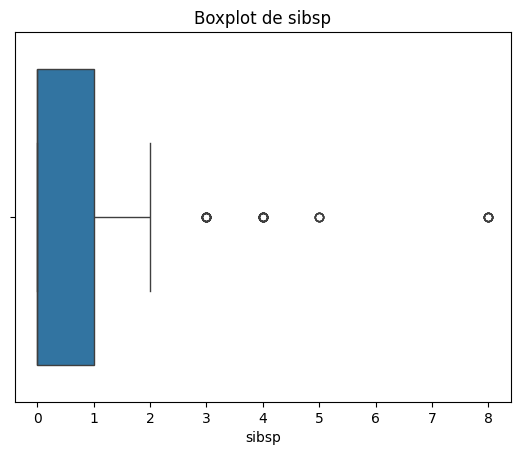

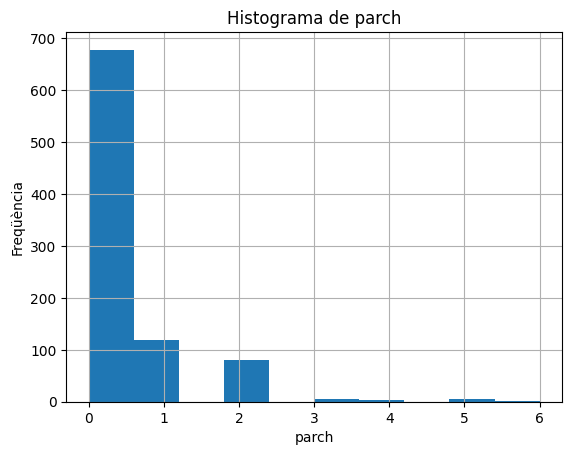

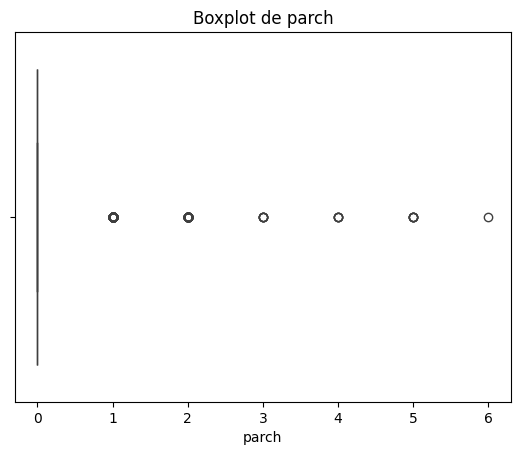

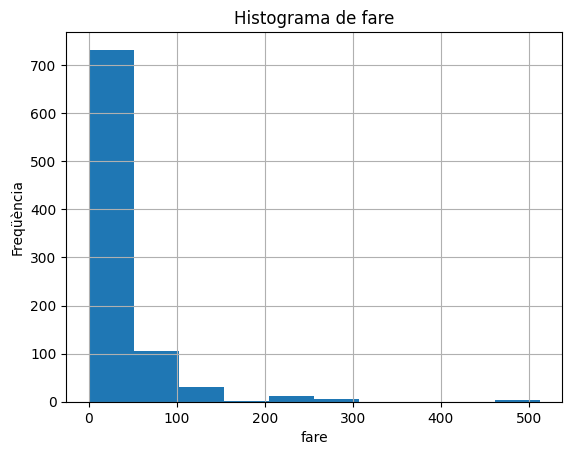

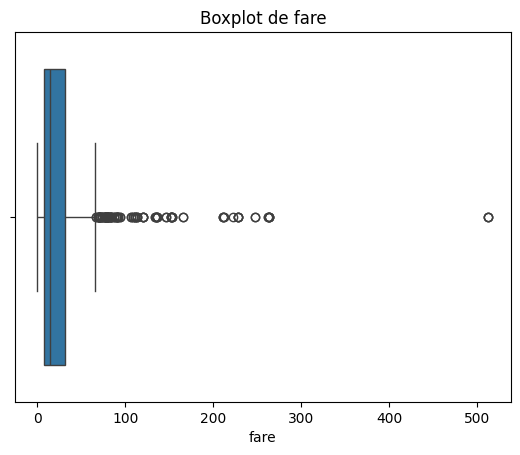

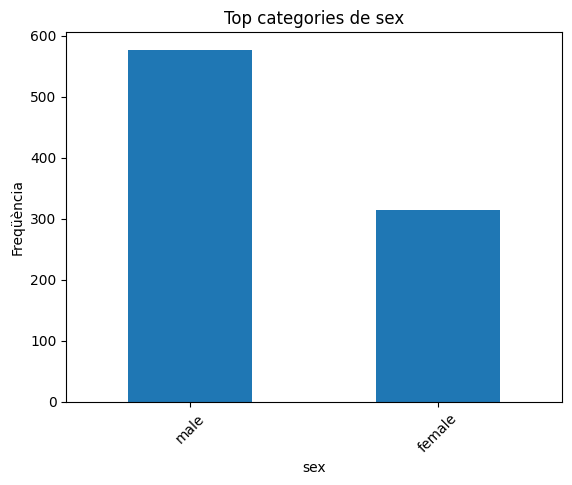

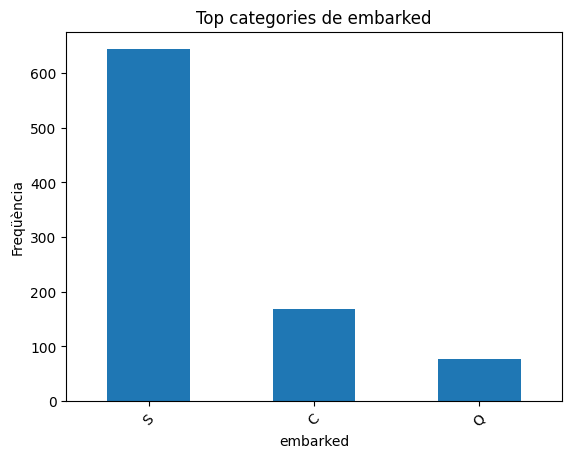

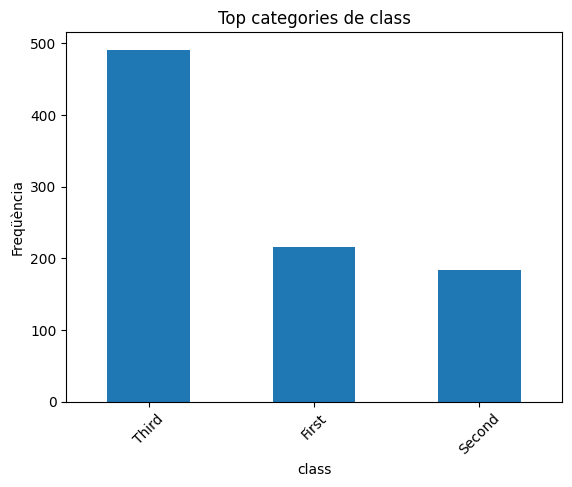

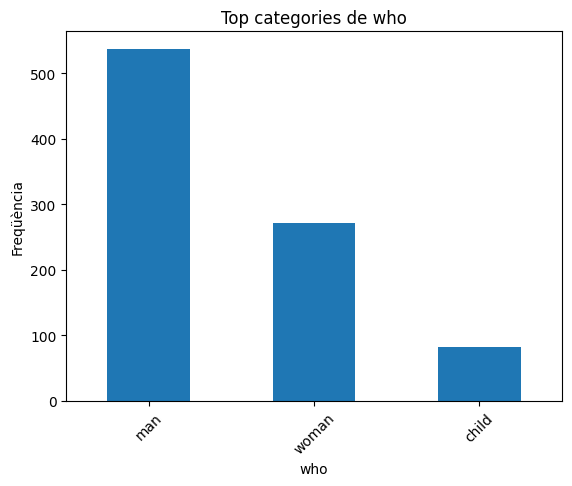

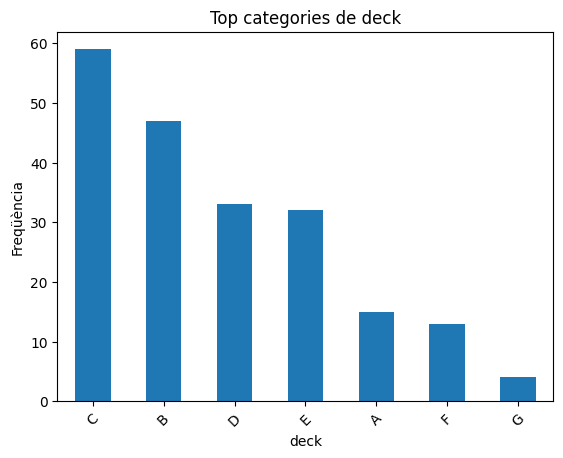

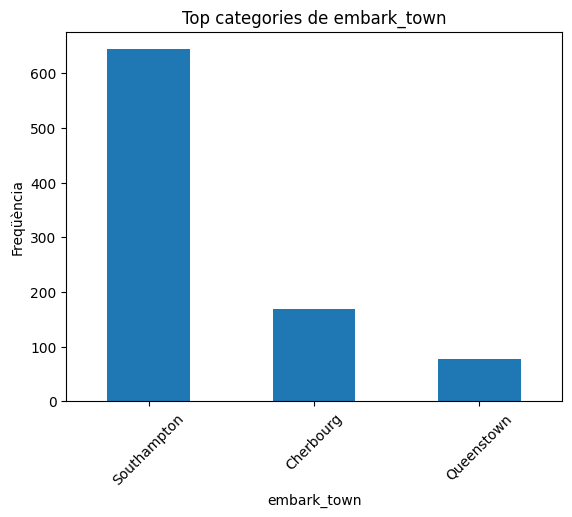

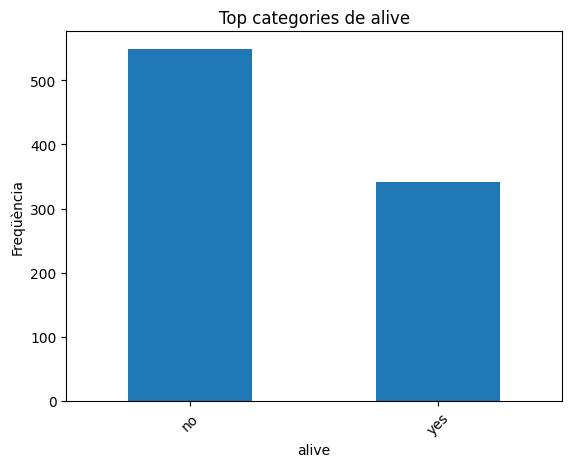

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def grafics(df, carpeta_sortida= 'grafics_sprint10'):
    os.makedirs(carpeta_sortida, exist_ok= True) # Creem la carpeta de sortida per als gràfics

    # NUMÈRIQUES
    for col in df.select_dtypes(include='number'):
        
        # Histograma
        plt.figure()
        df[col].hist(bins=10)
        plt.title(f'Histograma de {col}')
        plt.xlabel(col)
        plt.ylabel('Freqüència')
        plt.savefig(rf'{carpeta_sortida}\histo_{col}.png')
        plt.show()
        plt.close() #per evitar que es superposin

        # Boxplot
        plt.figure()
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot de {col}')
        plt.savefig(rf'{carpeta_sortida}\boxplot_{col}.png')
        plt.show()
        plt.close()

    # CATEGÒRIQUES (Barres)   
    for col in df.select_dtypes(include=['object', 'category']):
        plt.figure()
        df[col].value_counts().head(10).plot(kind='bar')
        plt.title(f'Top categories de {col}')
        plt.xticks(rotation=45) # Millora la lectura d'etiquetes llargues
        plt.ylabel('Freqüència')
        plt.savefig(rf'{carpeta_sortida}\grafico_barras_frecuencia_{col}.png')
        plt.show()
        plt.close()

    # DATES (Barres per any)
    for col in df.select_dtypes(include='datetime'):
        plt.figure()
        df[col].dt.year.value_counts().sort_index().plot(kind='bar')
        plt.title(f'Distribució temporal de {col}')
        plt.savefig(rf'{carpeta_sortida}\grafico_fechas_frecuencia_{col}.png')
        plt.show()
        plt.close()

# Exemple d'ús amb Seaborn
df_exemple = sns.load_dataset('titanic')
grafics(df_exemple)

2. Carrega l'arxiu matriu_distancies.xlsx a pandas, de manera que els noms de files i els noms de columnes siguin els de les ciutats. Borra "Las Palmas de Gran Canaria" i "Palma" perquè poguem fer el trajecte en cotxe.

Font: Mejores Rutas

Ens interessa visitar totes les ciutats principals d'Espanya recorrent la mínima distància possible.

No cal que ho facis de forma òptima, ens interessa que desenvolupis una solució raonable utilitzant les eines que tens actualment.

Per exemple, una aproximació senzilla (que no òptima) seria anant sempre a la ciutat més propera que no haguem visitat encara

Fes una funció que donada la matriu de distàncies i la ciutat d'origen, faci una proposta de ruta que sigui el més curta possible que puguis, retornant una llista amb l'ordre de visita. Dóna també la distància total recorreguda.

(EXTRA) Des de quina ciutat la ruta seria més curta amb l'algoritme plantejat

In [30]:
matriu_distancies = pd.read_excel('matriu_distancies.xlsx', index_col=0)

# Neteja de noms
matriu_distancies.index = matriu_distancies.index.str.strip()
matriu_distancies.columns = matriu_distancies.columns.str.strip()

# Eliminar ciutats insulars
matriu_distancies = matriu_distancies.drop(
    index=['Palma', 'Las Palmas de Gran Canaria'],
    columns=['Palma', 'Las Palmas de Gran Canaria'],
    errors='ignore'
)

def calcul_recorregut(matriu_distancies, ciutat_origen):

    # Comprovar que la ciutat existeix
    if ciutat_origen not in matriu_distancies.index:
        print("La ciutat indicada no existeix a la matriu.")
        return

    # Conjunt de ciutats no visitades
    no_visitades = set(matriu_distancies.index)

    # Eliminar ciutat inicial
    no_visitades.remove(ciutat_origen)

    # Variables inicials
    ciutat_actual = ciutat_origen
    ruta = [ciutat_origen]
    distancia_total = 0

    # Algoritme del veí més proper
    while no_visitades:

        # Buscar la ciutat no visitada més propera
        propera_ciutat = min(
            no_visitades,
            key=lambda ciutat: matriu_distancies.loc[ciutat_actual, ciutat]
        )

        # Sumar distància
        distancia = matriu_distancies.loc[ciutat_actual, propera_ciutat]
        distancia_total += distancia

        # Actualitzar ruta
        ruta.append(propera_ciutat)

        # Actualitzar ciutat actual
        ciutat_actual = propera_ciutat

        # Eliminar de no visitades
        no_visitades.remove(propera_ciutat)
    
    # Tornar a l'origen
    distancia_total += matriu_distancies.loc[ciutat_actual, ciutat_origen]
    ruta.append(ciutat_origen)

    # Mostrar resultat
    print(f"\nCiutat d'origen: {ciutat_origen}")
    print(f"Distància total recorreguda: {distancia_total} km")
    print("Ruta proposada:")
    print(" -> ".join(ruta))

    return ruta, distancia_total

ciutat_origen = input("Digues la ciutat d'origen: ")
calcul_recorregut(matriu_distancies, ciutat_origen)


Ciutat d'origen: Sevilla
Distància total recorreguda: 3787.0 km
Ruta proposada:
Sevilla -> Córdoba -> Málaga -> Murcia -> Alicante -> Valencia -> Zaragoza -> Bilbao -> Gijón -> Valladolid -> Vigo -> Hospitalet de Llobregat -> Barcelona -> Sevilla


(['Sevilla',
  'Córdoba',
  'Málaga',
  'Murcia',
  'Alicante',
  'Valencia',
  'Zaragoza',
  'Bilbao',
  'Gijón',
  'Valladolid',
  'Vigo',
  'Hospitalet de Llobregat',
  'Barcelona',
  'Sevilla'],
 np.float64(3787.0))

In [31]:
# EXTRA: MILLOR CIUTAT D'ORIGEN

millor_ciutat = None
millor_distancia = float('inf')
millor_ruta = None

# Provar totes les ciutats com origen
for ciutat in matriu_distancies.index:

    ruta, distancia = calcul_recorregut(matriu_distancies, ciutat)

    # Guardar la millor solució
    if distancia < millor_distancia:
        millor_distancia = distancia
        millor_ciutat = ciutat
        millor_ruta = ruta

# Mostrar resultat final
print("\n** MILLOR RUTA TROBADA **")
print(f"Millor ciutat d'origen: {millor_ciutat}")
print(f"Distància total mínima: {millor_distancia} km")

print("\nRuta:")
print(" -> ".join(millor_ruta))


Ciutat d'origen: Barcelona
Distància total recorreguda: 3686.0 km
Ruta proposada:
Barcelona -> Hospitalet de Llobregat -> Zaragoza -> Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla -> Málaga -> Valladolid -> Gijón -> Bilbao -> Vigo -> Barcelona

Ciutat d'origen: Valencia
Distància total recorreguda: 3966.0 km
Ruta proposada:
Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla -> Málaga -> Valladolid -> Gijón -> Bilbao -> Zaragoza -> Hospitalet de Llobregat -> Barcelona -> Vigo -> Valencia

Ciutat d'origen: Sevilla
Distància total recorreguda: 3787.0 km
Ruta proposada:
Sevilla -> Córdoba -> Málaga -> Murcia -> Alicante -> Valencia -> Zaragoza -> Bilbao -> Gijón -> Valladolid -> Vigo -> Hospitalet de Llobregat -> Barcelona -> Sevilla

Ciutat d'origen: Zaragoza
Distància total recorreguda: 4067.0 km
Ruta proposada:
Zaragoza -> Valencia -> Alicante -> Murcia -> Córdoba -> Sevilla -> Málaga -> Valladolid -> Gijón -> Bilbao -> Hospitalet de Llobregat -> Barcelona -> Vigo -> Zaragoza
